In [3]:
import pandas as pd

reg = pd.read_csv('reg_data.csv', sep=';')
auth = pd.read_csv('auth_data.csv', sep=';')
ab = pd.read_csv('ab_test.csv', sep=';')

for name, df in [('注册表 reg', reg), ('登录表 auth', auth), ('AB测试表 ab', ab)]:
    print(f"\n=== {name} ===")
    print("形状：", df.shape)
    print("字段：", df.columns.tolist())
    print(df.head(3))
    print("缺失值：\n", df.isnull().sum())
    print("-" * 50)


=== 注册表 reg ===
形状： (1000000, 2)
字段： ['reg_ts', 'uid']
      reg_ts  uid
0  911382223    1
1  932683089    2
2  947802447    3
缺失值：
 reg_ts    0
uid       0
dtype: int64
--------------------------------------------------

=== 登录表 auth ===
形状： (9601013, 2)
字段： ['auth_ts', 'uid']
     auth_ts  uid
0  911382223    1
1  932683089    2
2  932921206    2
缺失值：
 auth_ts    0
uid        0
dtype: int64
--------------------------------------------------

=== AB测试表 ab ===
形状： (404770, 3)
字段： ['user_id', 'revenue', 'testgroup']
   user_id  revenue testgroup
0        1        0         b
1        2        0         a
2        3        0         a
缺失值：
 user_id      0
revenue      0
testgroup    0
dtype: int64
--------------------------------------------------


In [4]:
import pandas as pd

# ===== 1. 时间戳转换 =====
reg['reg_date'] = pd.to_datetime(reg['reg_ts'], unit='s').dt.date
auth['auth_date'] = pd.to_datetime(auth['auth_ts'], unit='s').dt.date

print("注册时间范围：", reg['reg_date'].min(), "→", reg['reg_date'].max())
print("登录时间范围：", auth['auth_date'].min(), "→", auth['auth_date'].max())

注册时间范围： 1998-11-18 → 2020-09-23
登录时间范围： 1998-11-18 → 2020-09-23


In [5]:
# ===== 2. 去重 =====
print("auth 去重前：", len(auth))
auth = auth.drop_duplicates()
print("auth 去重后：", len(auth))

print("reg 去重前：", len(reg))
reg = reg.drop_duplicates(subset=['uid'])
print("reg 去重后：", len(reg))

auth 去重前： 9601013
auth 去重后： 9601013
reg 去重前： 1000000
reg 去重后： 1000000


In [6]:
# ===== 3. 查看数据分布 =====
# 每日新增用户数
daily_reg = reg.groupby('reg_date')['uid'].count().reset_index()
daily_reg.columns = ['date', 'new_users']
print("\n每日新增用户（前5天）：")
print(daily_reg.head())

# AB测试分组分布
print("\nAB测试分组：")
print(ab['testgroup'].value_counts())

# 付费用户数
print("\n付费用户数：", (ab['revenue'] > 0).sum())
print("总用户数：", len(ab))
print("付费率：", round((ab['revenue'] > 0).sum() / len(ab) * 100, 2), "%")


每日新增用户（前5天）：
         date  new_users
0  1998-11-18          1
1  1999-07-22          1
2  2000-01-13          1
3  2000-05-28          1
4  2000-09-16          1

AB测试分组：
testgroup
b    202667
a    202103
Name: count, dtype: int64

付费用户数： 3733
总用户数： 404770
付费率： 0.92 %


In [7]:
# ===== 1. 聚焦最近一年数据（2019-10 到 2020-09）=====
# 取最近12个月
auth['auth_date'] = pd.to_datetime(auth['auth_date'])
reg['reg_date'] = pd.to_datetime(reg['reg_date'])

start = pd.to_datetime('2019-10-01')
end = pd.to_datetime('2020-09-23')

auth_recent = auth[(auth['auth_date'] >= start) & (auth['auth_date'] <= end)]
reg_recent = reg[(reg['reg_date'] >= start) & (reg['reg_date'] <= end)]

print("近12个月登录记录：", len(auth_recent))
print("近12个月新增用户：", len(reg_recent))

近12个月登录记录： 4288321
近12个月新增用户： 445523


In [8]:
# ===== 2. DAU（日活跃用户数）=====
dau = auth_recent.groupby('auth_date')['uid'].nunique().reset_index()
dau.columns = ['date', 'dau']

print("DAU 统计：")
print(dau.describe().round(0))
print("\n平均 DAU：", round(dau['dau'].mean(), 0))
print("最高 DAU：", dau['dau'].max(), "日期：", dau.loc[dau['dau'].idxmax(), 'date'])

DAU 统计：
                      date      dau
count                  359    359.0
mean   2020-03-28 00:00:00  11945.0
min    2019-10-01 00:00:00   8722.0
25%    2019-12-29 12:00:00  10165.0
50%    2020-03-28 00:00:00  11793.0
75%    2020-06-25 12:00:00  13696.0
max    2020-09-23 00:00:00  15948.0
std                    NaN   2050.0

平均 DAU： 11945.0
最高 DAU： 15948 日期： 2020-09-21 00:00:00


In [9]:
# ===== 3. 每日新增用户 =====
daily_new = reg_recent.groupby('reg_date')['uid'].count().reset_index()
daily_new.columns = ['date', 'new_users']

print("\n每日新增用户统计：")
print(daily_new.describe().round(0))
print("平均每日新增：", round(daily_new['new_users'].mean(), 0))


每日新增用户统计：
                      date  new_users
count                  359      359.0
mean   2020-03-28 00:00:00     1241.0
min    2019-10-01 00:00:00      913.0
25%    2019-12-29 12:00:00     1056.0
50%    2020-03-28 00:00:00     1223.0
75%    2020-06-25 12:00:00     1416.0
max    2020-09-23 00:00:00     1641.0
std                    NaN      211.0
平均每日新增： 1241.0


In [10]:
# ===== 4. 月度 DAU 趋势 =====
dau['month'] = dau['date'].dt.to_period('M')
monthly_dau = dau.groupby('month')['dau'].mean().reset_index()
monthly_dau.columns = ['month', 'avg_dau']
monthly_dau['month'] = monthly_dau['month'].astype(str)

print("\n月度平均 DAU：")
print(monthly_dau.to_string(index=False))


月度平均 DAU：
  month      avg_dau
2019-10  8978.838710
2019-11  9470.833333
2019-12  9947.580645
2020-01 10453.096774
2020-02 10966.931034
2020-03 11550.741935
2020-04 12161.000000
2020-05 12776.483871
2020-06 13450.166667
2020-07 14173.967742
2020-08 14892.677419
2020-09 15297.608696


In [11]:
# ===== 次日留存 & 7日留存 =====

# 取近12个月新注册用户
reg_recent2 = reg_recent[['uid', 'reg_date']].copy()
reg_recent2['reg_date'] = pd.to_datetime(reg_recent2['reg_date'])

# 登录表
auth_dates = auth_recent[['uid', 'auth_date']].copy()
auth_dates['auth_date'] = pd.to_datetime(auth_dates['auth_date'])

# 合并：注册用户 + 登录记录
merged = reg_recent2.merge(auth_dates, on='uid', how='left')
merged['days_diff'] = (merged['auth_date'] - merged['reg_date']).dt.days

print("合并完成，总行数：", len(merged))

合并完成，总行数： 1779563


In [12]:
# ===== 计算各日留存率 =====
total_users = reg_recent2['uid'].nunique()

retention = {}
for day in [1, 3, 7, 14, 30]:
    retained = merged[merged['days_diff'] == day]['uid'].nunique()
    retention[f'Day{day}'] = round(retained / total_users * 100, 2)

print("\n=== 留存率 ===")
for k, v in retention.items():
    print(f"{k} 留存率：{v}%")


=== 留存率 ===
Day1 留存率：2.01%
Day3 留存率：4.56%
Day7 留存率：5.68%
Day14 留存率：4.34%
Day30 留存率：2.53%


In [13]:
# ===== 流失率 =====
# 注册后7天内没有登录过 = 流失
active_7d = merged[merged['days_diff'].between(1, 7)]['uid'].unique()
churned = total_users - len(active_7d)
churn_rate = round(churned / total_users * 100, 2)

print(f"\n7日内流失用户数：{churned}")
print(f"7日流失率：{churn_rate}%")


7日内流失用户数：340294
7日流失率：76.38%


In [14]:
# ===== ARPU / ARPPU / 付费率 =====

total_ab_users = len(ab)
paying_users = ab[ab['revenue'] > 0]
paying_count = len(paying_users)

# 付费率
payment_rate = round(paying_count / total_ab_users * 100, 2)

# ARPU = 总收入 / 总用户数
total_revenue = ab['revenue'].sum()
arpu = round(total_revenue / total_ab_users, 4)

# ARPPU = 总收入 / 付费用户数
arppu = round(total_revenue / paying_count, 2)

print("=== 付费指标 ===")
print(f"总用户数：{total_ab_users:,}")
print(f"付费用户数：{paying_count:,}")
print(f"付费率：{payment_rate}%")
print(f"总收入：{total_revenue:,}")
print(f"ARPU：{arpu}")
print(f"ARPPU：{arppu}")

=== 付费指标 ===
总用户数：404,770
付费用户数：3,733
付费率：0.92%
总收入：10,557,792
ARPU：26.0834
ARPPU：2828.23


In [15]:
# ===== AB测试对比：a组 vs b组 =====
ab_group = ab.groupby('testgroup').agg(
    用户数=('user_id', 'count'),
    付费用户数=('revenue', lambda x: (x > 0).sum()),
    总收入=('revenue', 'sum'),
).reset_index()

ab_group['付费率'] = round(ab_group['付费用户数'] / ab_group['用户数'] * 100, 2)
ab_group['ARPU'] = round(ab_group['总收入'] / ab_group['用户数'], 4)
ab_group['ARPPU'] = round(ab_group['总收入'] / ab_group['付费用户数'], 2)

print("\n=== AB测试对比 ===")
print(ab_group.to_string(index=False))


=== AB测试对比 ===
testgroup    用户数  付费用户数     总收入  付费率    ARPU   ARPPU
        a 202103   1928 5136189 0.95 25.4137 2664.00
        b 202667   1805 5421603 0.89 26.7513 3003.66


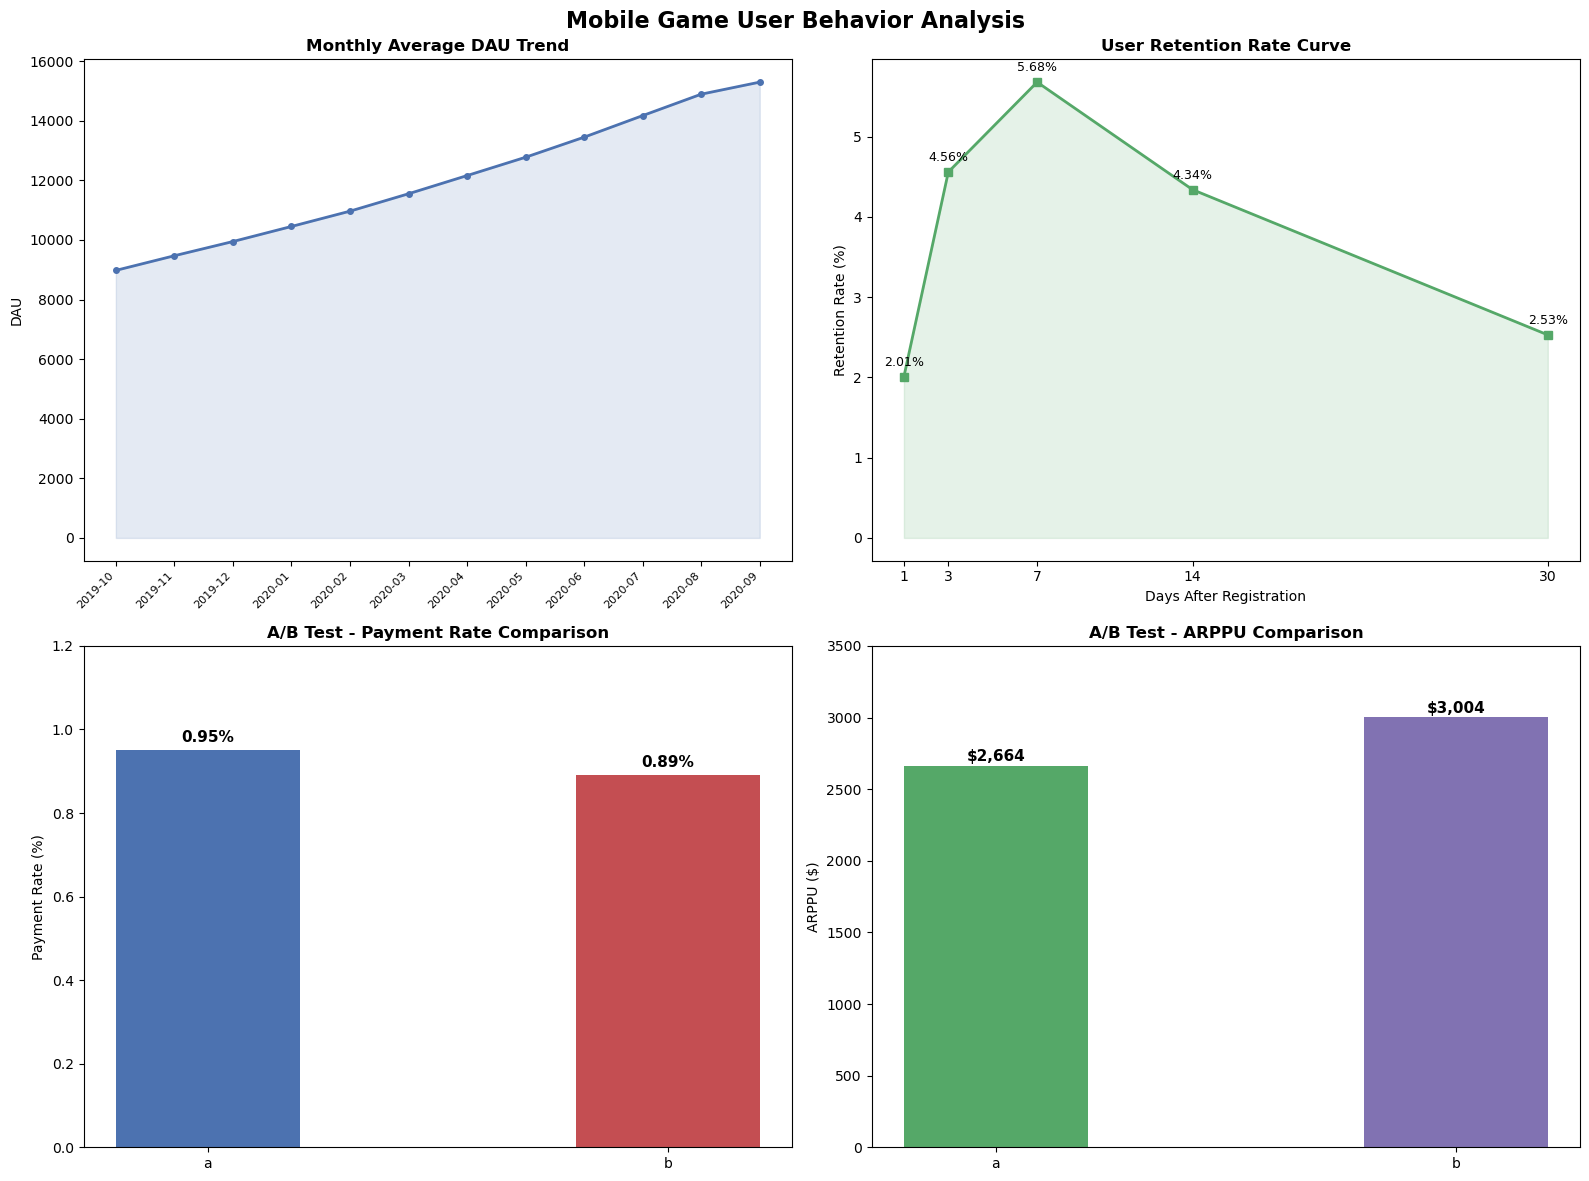

✓ 图表已保存


In [16]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Mobile Game User Behavior Analysis', fontsize=16, fontweight='bold')

# ===== 图1：月度 DAU 趋势 =====
ax1 = axes[0, 0]
ax1.plot(monthly_dau['month'], monthly_dau['avg_dau'],
         color='#4C72B0', linewidth=2, marker='o', markersize=4)
ax1.fill_between(range(len(monthly_dau)), monthly_dau['avg_dau'],
                 alpha=0.15, color='#4C72B0')
ax1.set_title('Monthly Average DAU Trend', fontweight='bold')
ax1.set_ylabel('DAU')
ax1.set_xticks(range(len(monthly_dau)))
ax1.set_xticklabels(monthly_dau['month'], rotation=45, ha='right', fontsize=8)

# ===== 图2：用户留存率曲线 =====
ax2 = axes[0, 1]
days = [1, 3, 7, 14, 30]
rates = list(retention.values())
ax2.plot(days, rates, color='#55A868', linewidth=2, marker='s', markersize=6)
ax2.fill_between(days, rates, alpha=0.15, color='#55A868')
ax2.set_title('User Retention Rate Curve', fontweight='bold')
ax2.set_xlabel('Days After Registration')
ax2.set_ylabel('Retention Rate (%)')
ax2.set_xticks(days)
for x, y in zip(days, rates):
    ax2.annotate(f'{y}%', (x, y), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=9)

# ===== 图3：AB测试付费率对比 =====
ax3 = axes[1, 0]
bars = ax3.bar(ab_group['testgroup'], ab_group['付费率'],
               color=['#4C72B0', '#C44E52'], width=0.4)
ax3.set_title('A/B Test - Payment Rate Comparison', fontweight='bold')
ax3.set_ylabel('Payment Rate (%)')
ax3.set_ylim(0, 1.2)
for bar, val in zip(bars, ab_group['付费率']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val}%', ha='center', fontsize=11, fontweight='bold')

# ===== 图4：AB测试 ARPPU 对比 =====
ax4 = axes[1, 1]
bars2 = ax4.bar(ab_group['testgroup'], ab_group['ARPPU'],
                color=['#55A868', '#8172B2'], width=0.4)
ax4.set_title('A/B Test - ARPPU Comparison', fontweight='bold')
ax4.set_ylabel('ARPPU ($)')
ax4.set_ylim(0, 3500)
for bar, val in zip(bars2, ab_group['ARPPU']):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'${val:,.0f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('game_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ 图表已保存")